<center><h1 style='color:red'>PLz upvote if you find it valuable!

# - Contents:

- **Import Libraries and Dataset**
- **Handle Missing Value**
- **Feature Engineering by OneHotEncoding**
- **PCA to visualize the datatset**
- **Linear Regression**
- **KNN Regression**
- **Ridge Regression**
- **Feature Normalization**
- **Lasso Regression**
- **Hyperparameter Tunning**
- **Random Forest Classifier**
- **Xgboost Classifier**

# Include Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


#filter out warnings
import warnings 
warnings.filterwarnings('ignore')

#To style plots
plt.style.use('fivethirtyeight')

#cycle the colors
from itertools import cycle
color_cycle = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

# Import dataset

In [2]:
train = pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train.shape

(1460, 81)

# EDA

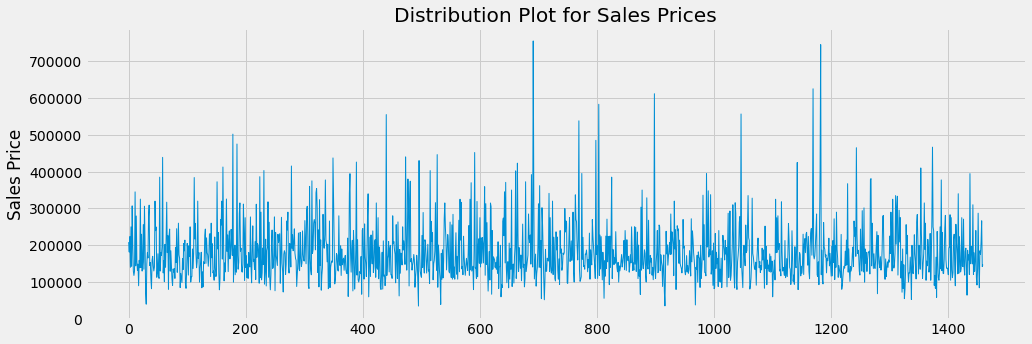

In [5]:
plt.figure(figsize=(15,5))
plt.plot(train.SalePrice,linewidth=1,color=next(color_cycle))
plt.title('Distribution Plot for Sales Prices')
plt.ylabel('Sales Price');

- **The above plot shows the distribution of sales price according to the index value.**
- **Let's sort the values according to sales price and re-draw the plot.**

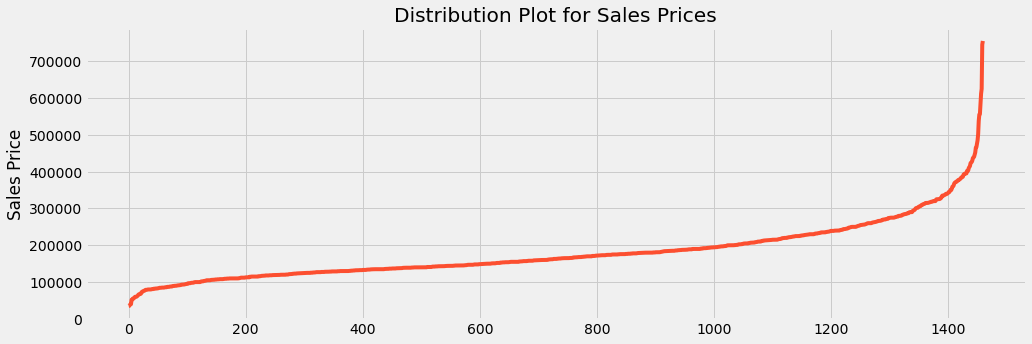

In [6]:
plt.figure(figsize=(15,5))
plt.plot(train.SalePrice.sort_values().reset_index(drop=True),color=next(color_cycle))
plt.title('Distribution Plot for Sales Prices')
plt.ylabel('Sales Price');

# Handle Missing Values



One of the best way to visualize Null values is through Heatmap

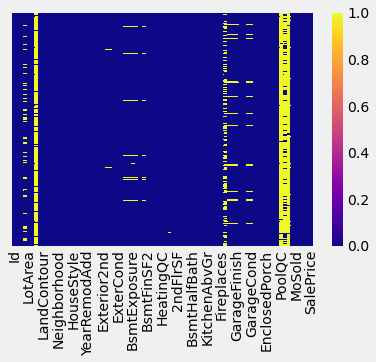

In [7]:
sns.heatmap(train.isnull(),yticklabels=False, cmap='plasma');

**The exact value number for null values can be seen by isnull() function.**

In [8]:
train.isnull().sum().sort_values(ascending=False)[0:19]

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageCond        81
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
BsmtExposure      38
BsmtFinType2      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
MasVnrType         8
Electrical         1
dtype: int64

In [9]:
test.isnull().sum().sort_values(ascending=False)[0:33]

PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
FireplaceQu      730
LotFrontage      227
GarageCond        78
GarageQual        78
GarageYrBlt       78
GarageFinish      78
GarageType        76
BsmtCond          45
BsmtQual          44
BsmtExposure      44
BsmtFinType1      42
BsmtFinType2      42
MasVnrType        16
MasVnrArea        15
MSZoning           4
BsmtHalfBath       2
Utilities          2
Functional         2
BsmtFullBath       2
BsmtFinSF2         1
BsmtFinSF1         1
Exterior2nd        1
BsmtUnfSF          1
TotalBsmtSF        1
SaleType           1
Exterior1st        1
KitchenQual        1
GarageArea         1
GarageCars         1
dtype: int64

**Let's fix the data One by One looking into features**

>  **- LonFrontage**

In [10]:
train.LotFrontage.head()

0    65.0
1    80.0
2    68.0
3    60.0
4    84.0
Name: LotFrontage, dtype: float64

`isnull().sum()` shows the number of missing values in the feature column.

In [11]:
train.LotFrontage.isnull().sum()

259

**Filling the null values with mean calculated of the feature**

In [12]:
train['LotFrontage'] = train['LotFrontage'].fillna(train.LotFrontage.mean())

In [13]:
test.LotFrontage.isnull().sum()

227

In [14]:
test['LotFrontage'] = test['LotFrontage'].fillna(test.LotFrontage.mean())

> **- Alley**

I m gonna drop the hole column!

In [15]:
train.Alley.value_counts(dropna=False)

NaN     1369
Grvl      50
Pave      41
Name: Alley, dtype: int64

In [16]:
train.drop(columns=['Alley'], inplace=True)

In [17]:
test.Alley.value_counts(dropna=False)

NaN     1352
Grvl      70
Pave      37
Name: Alley, dtype: int64

In [18]:
test.drop(columns=['Alley'], inplace=True)

Performing the same technique for all below mentioned columns.

> **- BsmtCond, BsmtQual, FirePlaceQu, GarageType, GarageCond, GarageFinish, GarageQual**

In [19]:
train.BsmtCond.value_counts(dropna=False)

TA     1311
Gd       65
Fa       45
NaN      37
Po        2
Name: BsmtCond, dtype: int64

In [20]:
train['BsmtCond'] = train['BsmtCond'].fillna(train.BsmtCond.mode()[0])

In [21]:
test['BsmtCond'] = test['BsmtCond'].fillna(test.BsmtCond.mode()[0])

Taking mode for all similar features like BsmtCond

In [22]:
list1 = ['BsmtQual', 'FireplaceQu', 'GarageType', 'GarageCond', 'GarageFinish', 'GarageQual', 'MasVnrType', 'MasVnrArea',
         'BsmtExposure','BsmtFinType2']

for item in list1:
    train[item] = train[item].fillna(train[item].mode()[0])
    test[item] = test[item].fillna(test[item].mode()[0])

**- GarageYrBlt, PoolQC, Fence, MiscFeature**

In [23]:
list1 = ['GarageYrBlt', 'PoolQC', 'Fence', 'MiscFeature']

for item in list1:
    train.drop(columns=item, inplace=True)
    test.drop(columns=item, inplace=True)

**Handle Remaining missing values**

In [24]:
train.isnull().sum().sort_values(ascending=False)

BsmtFinType1    37
Electrical       1
SalePrice        0
ExterQual        0
RoofStyle        0
                ..
KitchenAbvGr     0
KitchenQual      0
TotRmsAbvGrd     0
Functional       0
Id               0
Length: 76, dtype: int64

In [25]:
train.dropna(inplace=True)

In [26]:
train.drop(columns=['Id'], inplace=True)

In [27]:
train.shape

(1422, 75)

In [28]:
test.isnull().sum().sort_values(ascending=False)[0:17]

BsmtFinType1    42
MSZoning         4
Utilities        2
BsmtFullBath     2
BsmtHalfBath     2
Functional       2
GarageCars       1
BsmtFinSF1       1
BsmtFinSF2       1
BsmtUnfSF        1
SaleType         1
Exterior2nd      1
Exterior1st      1
KitchenQual      1
TotalBsmtSF      1
GarageArea       1
Condition2       0
dtype: int64

In [29]:
test['MSZoning']=test['MSZoning'].fillna(test['MSZoning'].mode()[0])

In [30]:
columns = ['BsmtFinType1', 'Utilities','BsmtFullBath', 'BsmtHalfBath', 'Functional', 'SaleType', 'Exterior2nd', 
           'Exterior1st', 'KitchenQual']
columns1 = ['GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',  'TotalBsmtSF', 'GarageArea']

for item in columns:
    test[item] = test[item].fillna(test[item].mode()[0])
for item in columns1:
    test[item] = test[item].fillna(test[item].mean())

In [31]:
test.drop(columns=['Id'], inplace=True)

In [32]:
test.shape

(1459, 74)

### Checking for missing values if any!

In [33]:
train.isnull().any().any()

False

In [34]:
test.isnull().any().any()

False

**Now the dataset is ready, we are now ready to explore it.**

In [35]:
fig = px.scatter(train,x=train.index, y='SalePrice', labels={'x':'Index'},
                 color=train.MSZoning, template="seaborn",
                 title='Sale Price distriution ---> MSZoning')
fig.show()

In [36]:
fig = px.scatter(train,x=train.index, y='SalePrice', labels={'x':'Index'},
                 color=train.Street, template="seaborn",
                 title='Sale Price distriution ---> Street')
fig.show()

**Street doesn't seems like a good feature**. Still we haven't seen correlation

In [37]:
train.LotConfig.unique()

array(['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3'], dtype=object)

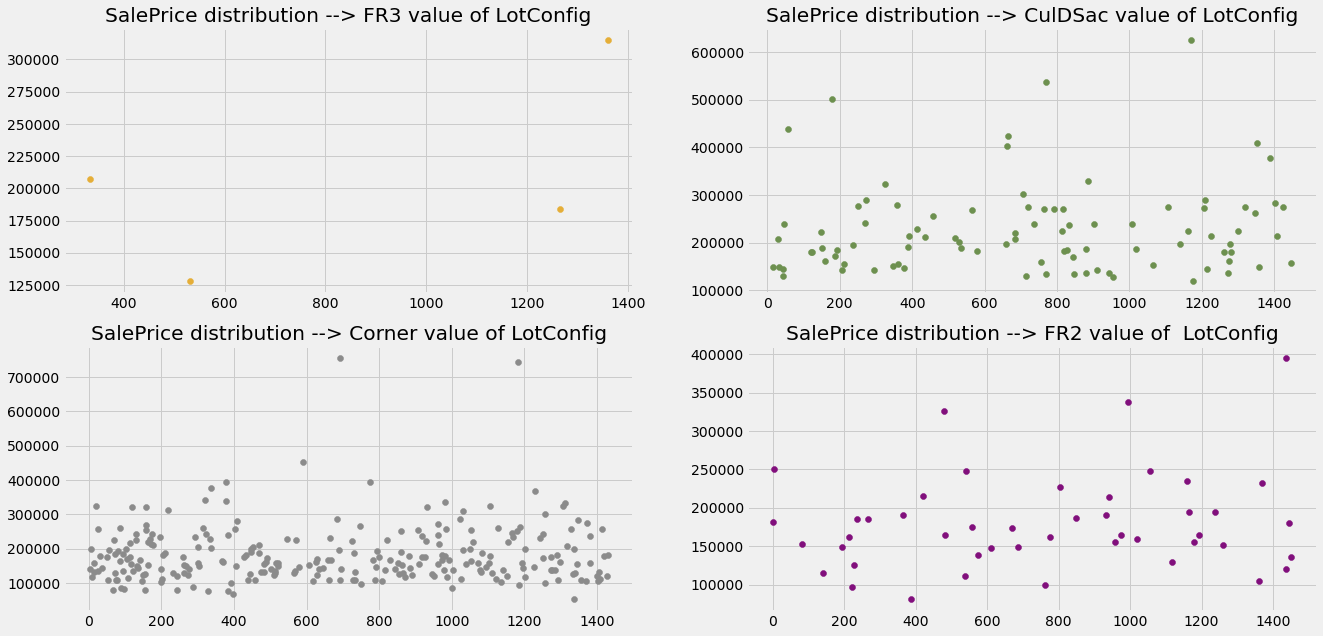

In [38]:
plt.figure(figsize=(20,10))

plt.subplot(2,2,1)
plt.scatter(x=train[train.LotConfig == 'FR3'].index,
           y=train[train.LotConfig == 'FR3'].SalePrice,color=next(color_cycle))
plt.title('SalePrice distribution --> FR3 value of LotConfig')

plt.subplot(2,2,2)
plt.scatter(x=train[train.LotConfig == 'CulDSac'].index,
           y=train[train.LotConfig == 'CulDSac'].SalePrice,color=next(color_cycle))
plt.title('SalePrice distribution --> CulDSac value of LotConfig')

plt.subplot(2,2,3)
plt.scatter(x=train[train.LotConfig == 'Corner'].index,
           y=train[train.LotConfig == 'Corner'].SalePrice,color=next(color_cycle))
plt.title('SalePrice distribution --> Corner value of LotConfig')

plt.subplot(2,2,4)
plt.scatter(x=train[train.LotConfig == 'FR2'].index,
           y=train[train.LotConfig == 'FR2'].SalePrice,color=next(color_cycle))
plt.title('SalePrice distribution --> FR2 value of  LotConfig');

## Feature Engineering by OneHotEncoding

In [39]:
columns = ['MSZoning', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish',
       'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']

In [40]:
len(columns)

39

In [41]:
final_df = pd.concat([train, test], axis=0)

In [42]:
final_df.shape

(2881, 75)

In [43]:
#A function that encodes categorical features
def One_hot_encoding(columns):
    df_final=final_df
    i=0
    for fields in columns:
        df1=pd.get_dummies(final_df[fields],drop_first=True)
        
        final_df.drop([fields],axis=1,inplace=True)
        if i==0:
            df_final=df1.copy()
        else:           
            df_final=pd.concat([df_final,df1],axis=1)
        i=i+1
       
        
    df_final=pd.concat([final_df,df_final],axis=1)
        
    return df_final

In [44]:
final_df = One_hot_encoding(columns)

In [45]:
final_df.shape

(2881, 235)

In [46]:
final_df =final_df.loc[:,~final_df.columns.duplicated()]

In [47]:
final_df.shape

(2881, 175)

**Let's seperate the data as it was!**

In [48]:
df_Train=final_df.iloc[:1422,:]
df_Test=final_df.iloc[1422:,:]

In [49]:
df_Test.drop(['SalePrice'],axis=1,inplace=True)

In [50]:
X_train_final=df_Train.drop(['SalePrice'],axis=1)
y_train_final=df_Train['SalePrice']

## PCA(Principle component analysis)

let’s visualize our final dataset by implementing PCA and plot the graph

In [51]:
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X_train_final)

my_columns = X_train_final.columns
new_df = pd.DataFrame(X_std, columns=my_columns)

In [52]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
df_pca = pca.fit_transform(new_df)

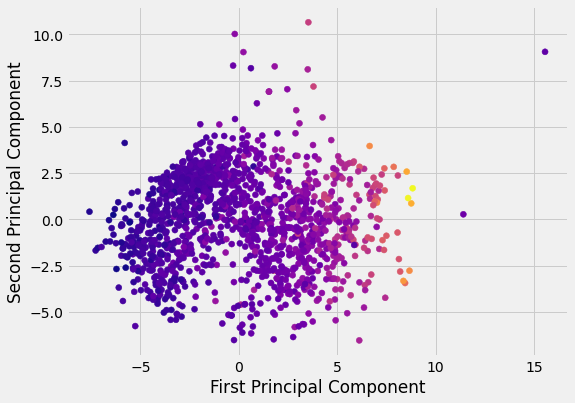

In [53]:
plt.figure(figsize =(8, 6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c = y_train_final, cmap ='plasma')
# labeling x and y axes
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component');

**Let's Start modeling now!**

# Linear Regression

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

#splitting the dataset as training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(X_train_final, y_train_final)

#building the model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

#Accuracy
print("R-Squared Value for Training Set: {:.3f}".format(linreg.score(X_train, y_train)))
print("R-Squared Value for Test Set: {:.3f}".format(linreg.score(X_test, y_test)))

R-Squared Value for Training Set: 0.906
R-Squared Value for Test Set: 0.513


### Note: Score() function in regression gives R2 value(R-Squared value) 

**let's try some other regression techniques.**

# KNN Regression

In [55]:
from sklearn.neighbors import KNeighborsRegressor

knnreg = KNeighborsRegressor(n_neighbors = 2)
knnreg.fit(X_train, y_train)

print('R-squared train score: {:.3f}'.format(knnreg.score(X_train, y_train)))
print('R-squared test score: {:.3f}'.format(knnreg.score(X_test, y_test)))

R-squared train score: 0.865
R-squared test score: 0.691


**It doen't perform well!**

# Ridge Regression

In [56]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X_train, y_train)

print('R-squared score (training): {:.3f}'.format(ridge.score(X_train, y_train)))
print('R-squared score (test): {:.3f}'.format(ridge.score(X_test, y_test)))

R-squared score (training): 0.885
R-squared score (test): 0.877


**Awesome!, let's try normalizing the features**

# Feature Normalization

`alpha` is a regularization parameter, you can try changing value from 1,5, 10 to 100. There is a huge impact of `alpha` on the model.

In [57]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=20)
ridge.fit(X_train_scaled, y_train)

print('R-squared score (training): {:.3f}'.format(ridge.score(X_train_scaled, y_train)))
print('R-squared score (test): {:.3f}'.format(ridge.score(X_test_scaled, y_test)))

R-squared score (training): 0.842
R-squared score (test): 0.867


# Lasso Regression

In [58]:
from sklearn.linear_model import Lasso

lasso = Lasso(max_iter = 10000)
lasso.fit(X_train, y_train)

print('R-squared score (training): {:.3f}'.format(lasso.score(X_train, y_train)))
print('R-squared score (test): {:.3f}'.format(lasso.score(X_test, y_test)))

R-squared score (training): 0.906
R-squared score (test): 0.531


**Almost Similar to ridge, let's try on normalized data**

In [59]:
lasso = Lasso(alpha=100, max_iter = 10000)
lasso.fit(X_train_scaled, y_train)

print('R-squared score (training): {:.3f}'.format(lasso.score(X_train_scaled, y_train)))
print('R-squared score (test): {:.3f}'.format(lasso.score(X_test_scaled, y_test)))

R-squared score (training): 0.873
R-squared score (test): 0.877


In [60]:
from sklearn.ensemble import RandomForestClassifier

regressor = RandomForestClassifier()

# Magic Weapon #1: Hyperparameter Tunning

In [61]:
from sklearn.model_selection import RandomizedSearchCV

n_estimators = [100, 500, 900]
criterion = ['gini', 'entropy']
depth = [3,5,10,15]
min_split=[2,3,4]
min_leaf=[2,3,4]
bootstrap = ['True', 'False']
verbose = [5]

hyperparameter_grid = {
    'n_estimators': n_estimators,
    'max_depth':depth,
    'criterion':criterion,
    'bootstrap':bootstrap,
    'verbose':verbose,
    'min_samples_split':min_split,
    'min_samples_leaf':min_leaf
    }

random_cv = RandomizedSearchCV(estimator=regressor,
                               param_distributions=hyperparameter_grid,
                               cv=5, 
                               scoring = 'neg_mean_absolute_error',
                               n_jobs = 4, 
                               return_train_score = True,
                               random_state=42)

In [62]:
random_cv.fit(X_train_final,y_train_final)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.1s remaining:    0.0s


building tree 1 of 900
building tree 2 of 900
building tree 3 of 900
building tree 4 of 900
building tree 5 of 900
building tree 6 of 900
building tree 7 of 900
building tree 8 of 900
building tree 9 of 900
building tree 10 of 900
building tree 11 of 900
building tree 12 of 900
building tree 13 of 900
building tree 14 of 900
building tree 15 of 900
building tree 16 of 900
building tree 17 of 900
building tree 18 of 900
building tree 19 of 900
building tree 20 of 900
building tree 21 of 900
building tree 22 of 900
building tree 23 of 900
building tree 24 of 900
building tree 25 of 900
building tree 26 of 900
building tree 27 of 900
building tree 28 of 900
building tree 29 of 900
building tree 30 of 900
building tree 31 of 900
building tree 32 of 900
building tree 33 of 900
building tree 34 of 900
building tree 35 of 900
building tree 36 of 900
building tree 37 of 900
building tree 38 of 900
building tree 39 of 900
building tree 40 of 900
building tree 41 of 900
building tree 42 of 900
b

[Parallel(n_jobs=1)]: Done 900 out of 900 | elapsed:   30.6s finished


RandomizedSearchCV(cv=5, error_score=nan,
                   estimator=RandomForestClassifier(bootstrap=True,
                                                    ccp_alpha=0.0,
                                                    class_weight=None,
                                                    criterion='gini',
                                                    max_depth=None,
                                                    max_features='auto',
                                                    max_leaf_nodes=None,
                                                    max_samples=None,
                                                    min_impurity_decrease=0.0,
                                                    min_impurity_split=None,
                                                    min_samples_leaf=1,
                                                    min_samples_split=2,
                                                    min_weight_fraction_leaf=0.0,
               

In [63]:
random_cv.best_estimator_

RandomForestClassifier(bootstrap='False', ccp_alpha=0.0, class_weight=None,
                       criterion='entropy', max_depth=10, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=3, min_samples_split=3,
                       min_weight_fraction_leaf=0.0, n_estimators=900,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=5, warm_start=False)

# Random Forest Classifier

In [64]:
regressor = RandomForestClassifier(bootstrap='False', class_weight=None,
                       criterion='entropy', max_depth=10, max_features='auto',
                       max_leaf_nodes=None, min_impurity_decrease=0.0,
                       min_impurity_split=None, min_samples_leaf=3,
                       min_samples_split=3, min_weight_fraction_leaf=0.0,
                       n_estimators=900, n_jobs=None, oob_score=False,
                       random_state=None, verbose=5, warm_start=False)

In [65]:
regressor.fit(X_train_final,y_train_final)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.1s remaining:    0.0s


building tree 1 of 900
building tree 2 of 900
building tree 3 of 900
building tree 4 of 900
building tree 5 of 900
building tree 6 of 900
building tree 7 of 900
building tree 8 of 900
building tree 9 of 900
building tree 10 of 900
building tree 11 of 900
building tree 12 of 900
building tree 13 of 900
building tree 14 of 900
building tree 15 of 900
building tree 16 of 900
building tree 17 of 900
building tree 18 of 900
building tree 19 of 900
building tree 20 of 900
building tree 21 of 900
building tree 22 of 900
building tree 23 of 900
building tree 24 of 900
building tree 25 of 900
building tree 26 of 900
building tree 27 of 900
building tree 28 of 900
building tree 29 of 900
building tree 30 of 900
building tree 31 of 900
building tree 32 of 900
building tree 33 of 900
building tree 34 of 900
building tree 35 of 900
building tree 36 of 900
building tree 37 of 900
building tree 38 of 900
building tree 39 of 900
building tree 40 of 900
building tree 41 of 900
building tree 42 of 900
b

[Parallel(n_jobs=1)]: Done 900 out of 900 | elapsed:   31.2s finished


RandomForestClassifier(bootstrap='False', ccp_alpha=0.0, class_weight=None,
                       criterion='entropy', max_depth=10, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=3, min_samples_split=3,
                       min_weight_fraction_leaf=0.0, n_estimators=900,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=5, warm_start=False)

In [66]:
y_pred = regressor.predict(df_Test)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done 900 out of 900 | elapsed:    3.8s finished


In [67]:
y_pred

array([110000., 158000., 173000., ..., 168000.,  93500., 250000.])

In [68]:
pred=pd.DataFrame(y_pred)
samp = pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')
sub = pd.concat([samp['Id'],pred], axis=1)
sub.columns=['Id','SalePrice']

In [69]:
sub

,Id,SalePrice
0,1461,110000.0
1,1462,158000.0
2,1463,173000.0
3,1464,173000.0
4,1465,153900.0
...,...,...
1454,2915,75000.0
1455,2916,88000.0
1456,2917,168000.0
1457,2918,93500.0


In [70]:
#sub.to_csv('My_sub.csv',index=False)

# Magic Weapon #2: Xgboost Classifier

In [71]:
import xgboost

In [72]:
regressor=xgboost.XGBRegressor()

In [73]:
n_estimators = [100, 500, 900, 1100, 1500]
max_depth = [2, 3, 5, 10, 15]
booster=['gbtree','gblinear']
learning_rate=[0.05,0.1,0.15,0.20]
min_child_weight=[1,2,3,4]
base_score=[0.25,0.5,0.75,1]

# Define the grid of hyperparameters to search
hyperparameter_grid = {
    'n_estimators': n_estimators,
    'max_depth':max_depth,
    'learning_rate':learning_rate,
    'min_child_weight':min_child_weight,
    'booster':booster,
    'base_score':base_score
    }
random_cv = RandomizedSearchCV(estimator=regressor,
            param_distributions=hyperparameter_grid,
            cv=5, n_iter=50,
            scoring = 'neg_mean_absolute_error',n_jobs = 4,
            verbose = 5, 
            return_train_score = True,
            random_state=42)

In [74]:
random_cv.fit(X_train_final,y_train_final)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   20.2s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:  3.1min
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:  6.2min
[Parallel(n_jobs=4)]: Done 250 out of 250 | elapsed:  9.8min finished


RandomizedSearchCV(cv=5, error_score=nan,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, gamma=None,
                                          gpu_id=None, importance_type='gain',
                                          interaction_constraints=None,
                                          learning_rate=None,
                                          max_delta_step=None, max_depth=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          n_...
                   iid='deprecated', n_iter=50, n_jobs=4,
                   param_distributions={'base_score': [0.25, 0.5, 0.75, 1],
                                        'booster': ['gbt

In [75]:
random_cv.best_estimator_

XGBRegressor(base_score=0.25, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
             importance_type='gain', interaction_constraints=None,
             learning_rate=0.1, max_delta_step=0, max_depth=2,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             n_estimators=900, n_jobs=0, num_parallel_tree=1,
             objective='reg:squarederror', random_state=0, reg_alpha=0,
             reg_lambda=1, scale_pos_weight=1, subsample=1, tree_method=None,
             validate_parameters=False, verbosity=None)

In [76]:
regressor = xgboost.XGBRegressor(base_score=0.25, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
             importance_type='gain', interaction_constraints='',
             learning_rate=0.1, max_delta_step=0, max_depth=2,
             min_child_weight=1, missing=None, monotone_constraints='()',
             n_estimators=900, n_jobs=0, num_parallel_tree=1,
             objective='reg:squarederror', random_state=0, reg_alpha=0,
             reg_lambda=1, scale_pos_weight=1, subsample=1, tree_method='exact',
             validate_parameters=1, verbosity=None)

In [77]:
regressor.fit(X_train_final,y_train_final)

[22:52:28] WARNING: /workspace/src/learner.cc:328: 
Parameters: { importance_type, missing, n_estimators } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.




XGBRegressor(base_score=0.25, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
             importance_type='gain', interaction_constraints='',
             learning_rate=0.1, max_delta_step=0, max_depth=2,
             min_child_weight=1, missing=nan, monotone_constraints='()',
             n_estimators=900, n_jobs=0, num_parallel_tree=1,
             objective='reg:squarederror', random_state=0, reg_alpha=0,
             reg_lambda=1, scale_pos_weight=1, subsample=1, tree_method='exact',
             validate_parameters=1, verbosity=None)

In [78]:
y_pred = regressor.predict(df_Test)

In [79]:
y_pred

array([114042.1 , 164575.23, 190523.47, ..., 175098.2 , 117959.04,
       233386.06], dtype=float32)

In [80]:
pred=pd.DataFrame(y_pred)
samp = pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')
sub = pd.concat([samp['Id'],pred], axis=1)
sub.columns=['Id','SalePrice']

In [81]:
sub

,Id,SalePrice
0,1461,114042.101562
1,1462,164575.234375
2,1463,190523.468750
3,1464,198186.234375
4,1465,189446.468750
...,...,...
1454,2915,86688.562500
1455,2916,68252.546875
1456,2917,175098.203125
1457,2918,117959.039062


In [82]:
#sub.to_csv('My_sub1.csv',index=False)